# Statistical analysis of DEAP benchmark results

This notebook loads the `deap_stress_results.csv` produced by
`stress_test_deap.py` and performs the standard statistical tests
for the paper: mean ranks, Friedman test, pairwise Wilcoxon with
Holm correction, and a critical difference diagram.

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`,
`autorank` (``pip install autorank``).

# 0. Fake data (remember to remove)

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Replicate the structure: 2 algorithms, 2 problems, 30 runs each
algorithms = ["GA (DEAP)", "ES (DEAP)"]
problems = [
    {"problem_name": "IOH-bbob-F1-D5-ins1", "fid": 1, "dimension": 5, "instance": 1},
    {"problem_name": "IOH-bbob-F2-D5-ins1", "fid": 2, "dimension": 5, "instance": 1},
]
n_runs = 30

rows = []
for prob in problems:
    for run in range(n_runs):
        for algo in algorithms:
            # Realistic objective values (sphere-like, decreasing with algorithm quality)
            base = np.random.uniform(10, 100) if algo == "GA (DEAP)" else np.random.uniform(1, 20)
            val = base + np.random.normal(0, base * 0.05)  # small noise
            rows.append({
                "algorithm": algo,
                "problem_name": prob["problem_name"],
                "fid": prob["fid"],
                "dimension": prob["dimension"],
                "instance": prob["instance"],
                "run": run,
                "best_objective": val,
            })

dummy_df = pd.DataFrame(rows)
dummy_df.to_csv("fake_stress_results.csv", index=False)
print("Done - 'fake_stress_results.csv' created with", len(dummy_df), "rows.")

Done - 'fake_stress_results.csv' created with 120 rows.


## 1.  Load the data

In [4]:
import pandas as pd
import numpy as np

# Adjust path if needed – this is the final CSV from the stress test
# df = pd.read_csv("deap_stress_results.csv")
df = pd.read_csv("fake_stress_results.csv")

print(f"Loaded {len(df)} runs")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 120 runs
Columns: ['algorithm', 'problem_name', 'fid', 'dimension', 'instance', 'run', 'best_objective']


,algorithm,problem_name,fid,dimension,instance,run,best_objective
0,GA (DEAP),IOH-bbob-F1-D5-ins1,1,5,1,0,41.278674
1,ES (DEAP),IOH-bbob-F1-D5-ins1,1,5,1,0,4.027101
2,GA (DEAP),IOH-bbob-F1-D5-ins1,1,5,1,1,15.439981
3,ES (DEAP),IOH-bbob-F1-D5-ins1,1,5,1,1,15.183647
4,GA (DEAP),IOH-bbob-F1-D5-ins1,1,5,1,2,11.508359


## 2.  Quick sanity checks

In [5]:
# Check that every algorithm/problem/run combination is present
grouped = df.groupby(["algorithm", "problem_name"]).size().unstack(fill_value=0)
assert grouped.min().min() == 30, "Missing runs detected!"
print("All 30 runs present for every combination.")
grouped.head()

All 30 runs present for every combination.


problem_name,IOH-bbob-F1-D5-ins1,IOH-bbob-F2-D5-ins1
algorithm,,
ES (DEAP),30,30
GA (DEAP),30,30


## 3.  Mean ranks and average performance

In [6]:
# Compute mean best objective per algorithm/problem
mean_per_alg_prob = df.groupby(["algorithm", "problem_name"])["best_objective"].mean().unstack()

# Rank algorithms per problem (1 = best, lower is better)
# (If objective is negative for maximisation problems, flip sign – our BBOB are min.)
ranks_per_problem = mean_per_alg_prob.rank(axis=0, ascending=True)

# Average rank
avg_ranks = ranks_per_problem.mean(axis=1).sort_values()
print("Average ranks (1 = best):")
print(avg_ranks)

Average ranks (1 = best):
algorithm
ES (DEAP)    1.0
GA (DEAP)    2.0
dtype: float64


## 4.  Visualise the performance distribution

/tmp/ipykernel_400584/174005814.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="algorithm", y="best_objective", palette="Set2", ax=ax)


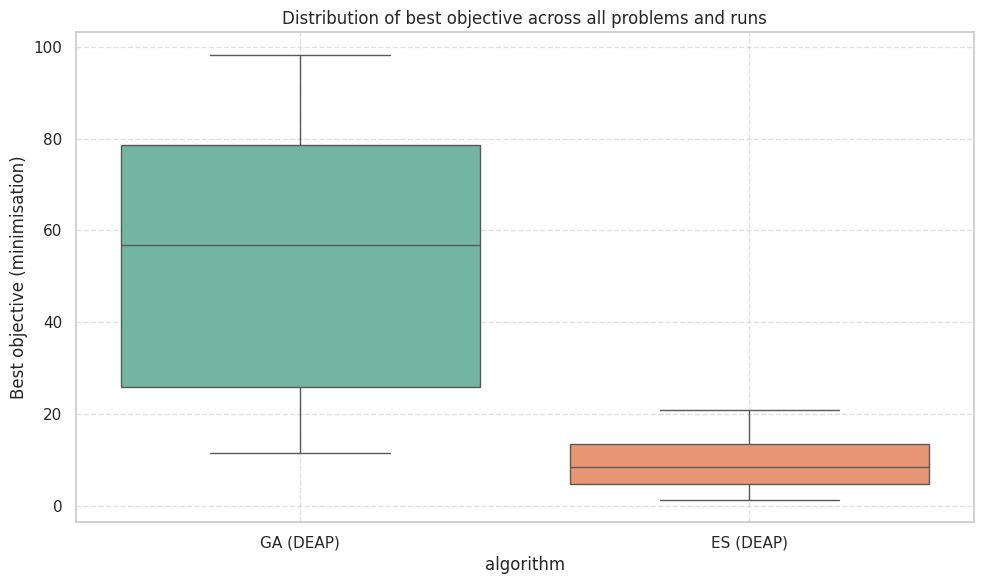

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Boxplot of best objectives across all problems
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="algorithm", y="best_objective", palette="Set2", ax=ax)
ax.set_ylabel("Best objective (minimisation)")
ax.set_title("Distribution of best objective across all problems and runs")
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5.  Statistical tests with autorank

In [8]:
from autorank import autorank, plot_stats

# autorank expects a DataFrame with one column per algorithm.
# We need the best objective per algorithm, paired by (problem, run).
pivot = df.pivot_table(
    index=["problem_name", "run"], columns="algorithm", values="best_objective"
)
pivot = pivot.dropna()  # just in case

result = autorank(pivot, alpha=0.05, verbose=True, order="ascending")
print(result)

Rejecting null hypothesis that data is normal for column ES (DEAP) (p=0.009540<0.025000)
Rejecting null hypothesis that data is normal for column GA (DEAP) (p=0.001267<0.025000)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000000<0.050000)
Using Wilcoxon's signed rank test (one-sided)
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
           meanrank     median       mad   ci_lower   ci_upper effect_size  \
ES (DEAP)  1.016667   8.364764  4.326588   5.310229  13.285327         0.0   
GA (DEAP)  1.983333  56.908803  25.04685  35.356168  77.662541   -1.821751   

            magnitude effect_size_above magnitude_above  
ES (DEAP)  negligible               0.0      negligible  
GA (DEAP)       large         -1.821751           large  
RankResult(rankdf=
           meanrank     median       mad   ci_lower   ci_upper effect_size  \
ES (DEAP)  1.016667   8.364764  4.326588  

In [10]:
# Critical difference diagram
fig = plot_stats(result, allow_insignificant=False)
# fig.set_size_inches(10, 4)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## 6.  Summary table for the paper

In [11]:
# Table of mean ± std per algorithm
summary = df.groupby("algorithm")["best_objective"].agg(["mean", "std", "min", "max"])
summary["rank"] = avg_ranks
summary = summary.sort_values("rank")
print(summary)

                mean        std        min        max  rank
algorithm                                                  
ES (DEAP)   9.311680   5.458106   1.224518  20.830182   1.0
GA (DEAP)  53.927579  28.158118  11.508359  98.325883   2.0


## 7.  Next steps

- Copy the resulting CD diagram into your paper.
- Open `experiment_data_stress/` with **IOHanalyzer** for
  ECDF curves, fixed‑target analysis, and performance profiles.
- This notebook can be re‑run with more algorithms once the
  other wrappers (PyGMO, Nevergrad, SciPy) are added to the
  experiment loop.